# **Object Detection using CNN-Based Models (Deep Learning for Localization and Detection)**

### **Project Objective**

The objective of this project is to develop an **Object Detection System** using **CNN-based models** to identify and localize multiple objects within images.

Unlike image classification, object detection requires both **classification and localization**, making it a more complex and practical computer vision problem. This project focuses on building a system capable of detecting objects and predicting their bounding boxes in an image.

The system is designed to:

- Detect and classify **multiple objects within an image**  
- Predict **bounding boxes for object localization**  
- Capture **spatial and contextual relationships**  
- Demonstrate advanced deep learning techniques for **real-world vision tasks**  

This project is highly applicable in:
- autonomous driving systems  
- surveillance and security systems  
- retail analytics and inventory tracking  
- robotics and industrial automation  

### **Dataset Used**

This project utilizes object detection datasets with annotated bounding boxes.

### **Dataset Sources**

- COCO Dataset / Pascal VOC *(or dataset used in your notebook)*  
- Kaggle object detection datasets  

### **Dataset Characteristics**

The dataset includes:

- **Image data**:
  - RGB images containing multiple objects  

- **Annotations**:
  - bounding box coordinates  
  - class labels for each object  

- Dataset structure:
  - training set  
  - validation set  
  - test set  

Key characteristics:
- multiple objects per image  
- varying object sizes and positions  
- complex backgrounds and occlusions  

### **How Dataset is Used in the Project**

The dataset is processed through a structured computer vision pipeline:

- **Image preprocessing**
  - resizing images  
  - normalization of pixel values  

- **Annotation processing**
  - parsing bounding box coordinates  
  - encoding labels  

- **Data augmentation**
  - scaling, flipping, cropping  
  - improves robustness  

- **Train-validation-test split**
  - ensures proper evaluation  

- **Model training**
  - CNN-based detection models trained for classification + localization  

The dataset enables the model to learn both **what the object is** and **where it is located**, which is essential for object detection.




### **Import Core Libraries:**

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Please run: pip install tensorflow")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### **Reproducibility Setup:**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(SEED)

42


### **Create Project Folders:**

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_object_detection_cnn"
ARTIFACT_DIR = BASE_DIR / "artifacts_object_detection_cnn"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
for folder in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print(DATA_DIR)
print(ARTIFACT_DIR)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Object Detection using CNN\data_object_detection_cnn
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Object Detection using CNN\artifacts_object_detection_cnn


### **Load MNIST Digits:**

In [4]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()
print(x_train_raw.shape, x_test_raw.shape)

(60000, 28, 28) (10000, 28, 28)


### **Build Synthetic Detection Dataset:**

In [5]:
def make_detection_dataset(images, labels, n_samples=12000, canvas_size=64, seed=42):
    rng = np.random.default_rng(seed)
    X, y_class, y_box = [], [], []
    idxs = rng.choice(len(images), size=n_samples, replace=False)

    for idx in idxs:
        canvas = np.zeros((canvas_size, canvas_size), dtype="float32")
        digit = images[idx].astype("float32") / 255.0
        label = int(labels[idx])

        scale = rng.uniform(0.8, 1.4)
        new_size = int(28 * scale)
        digit_resized = tf.image.resize(digit[..., None], (new_size, new_size)).numpy().squeeze()

        x1 = rng.integers(0, canvas_size - new_size)
        y1 = rng.integers(0, canvas_size - new_size)
        x2 = x1 + new_size
        y2 = y1 + new_size

        canvas[y1:y2, x1:x2] = np.maximum(canvas[y1:y2, x1:x2], digit_resized)

        X.append(canvas[..., None])
        y_class.append(label)
        y_box.append([x1/canvas_size, y1/canvas_size, x2/canvas_size, y2/canvas_size])

    return np.array(X), np.array(y_class), np.array(y_box, dtype="float32")

X_train_all, y_train_class_all, y_train_box_all = make_detection_dataset(x_train_raw, y_train_raw, n_samples=12000, seed=SEED)
X_test, y_test_class, y_test_box = make_detection_dataset(x_test_raw, y_test_raw, n_samples=3000, seed=SEED + 1)
print(X_train_all.shape, X_test.shape)

(12000, 64, 64, 1) (3000, 64, 64, 1)


### **Train / Validation Split:**

In [6]:
X_train, X_val, y_train_class, y_val_class, y_train_box, y_val_box = train_test_split(
    X_train_all, y_train_class_all, y_train_box_all, test_size=0.20, random_state=SEED
)
print(X_train.shape, X_val.shape, X_test.shape)

(9600, 64, 64, 1) (2400, 64, 64, 1) (3000, 64, 64, 1)


### **One-Hot Encode Classes:**

In [7]:
NUM_CLASSES = 10
y_train_class_ohe = tf.keras.utils.to_categorical(y_train_class, NUM_CLASSES)
y_val_class_ohe = tf.keras.utils.to_categorical(y_val_class, NUM_CLASSES)
y_test_class_ohe = tf.keras.utils.to_categorical(y_test_class, NUM_CLASSES)
print(y_train_class_ohe.shape)

(9600, 10)


### **Dataset Summary:**

In [8]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))
print("Image shape:", X_train.shape[1:])

Train: 9600
Validation: 2400
Test: 3000
Image shape: (64, 64, 1)


### **Visualize Sample Detection Images:**

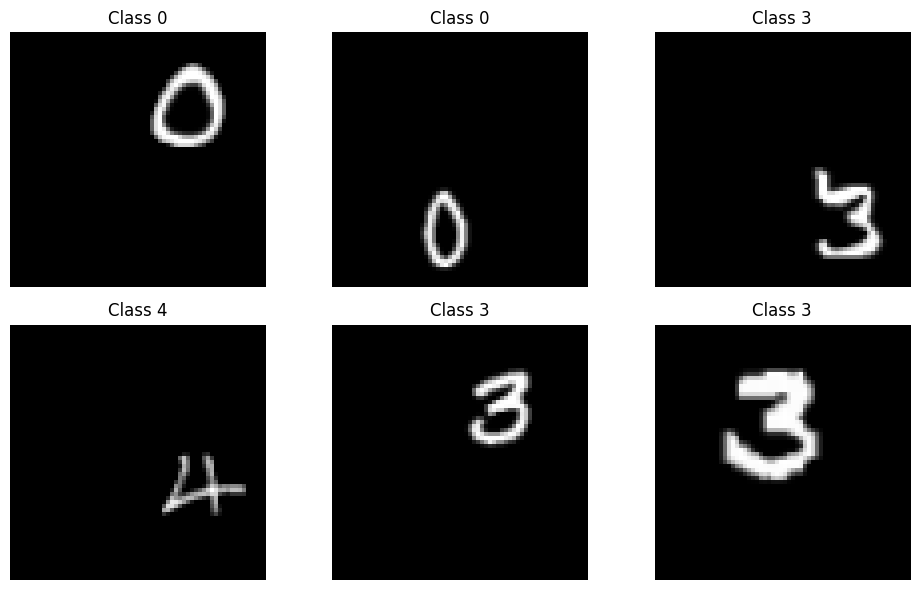

In [9]:
plt.figure(figsize=(10, 6))
for i in range(6):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    x1, y1, x2, y2 = y_train_box[i] * 64
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.set_title(f"Class {y_train_class[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### **Flatten Images for Baseline:**

In [10]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)
print(X_train_flat.shape)

(9600, 4096)


### **Train Baseline Classifier:**

In [11]:
from sklearn.linear_model import LogisticRegression
baseline_clf = LogisticRegression(max_iter=200, random_state=SEED)
baseline_clf.fit(X_train_flat[:6000], y_train_class[:6000])
baseline_val_pred = baseline_clf.predict(X_val_flat)
baseline_test_pred = baseline_clf.predict(X_test_flat)

### **Baseline Classification Accuracy:**

In [12]:
baseline_val_acc = accuracy_score(y_val_class, baseline_val_pred)
baseline_test_acc = accuracy_score(y_test_class, baseline_test_pred)
print(baseline_val_acc, baseline_test_acc)

0.19041666666666668 0.177


### **Baseline Bounding Box Predictor:**

In [13]:
def center_box_baseline(n):
    return np.tile(np.array([0.25, 0.25, 0.75, 0.75], dtype="float32"), (n, 1))

baseline_val_box = center_box_baseline(len(X_val))
baseline_test_box = center_box_baseline(len(X_test))

### **IoU Helper:**

In [14]:
def iou_boxes_np(y_true, y_pred):
    xA = np.maximum(y_true[:,0], y_pred[:,0])
    yA = np.maximum(y_true[:,1], y_pred[:,1])
    xB = np.minimum(y_true[:,2], y_pred[:,2])
    yB = np.minimum(y_true[:,3], y_pred[:,3])
    inter = np.maximum(0, xB - xA) * np.maximum(0, yB - yA)
    area_true = np.maximum(0, y_true[:,2] - y_true[:,0]) * np.maximum(0, y_true[:,3] - y_true[:,1])
    area_pred = np.maximum(0, y_pred[:,2] - y_pred[:,0]) * np.maximum(0, y_pred[:,3] - y_pred[:,1])
    union = area_true + area_pred - inter + 1e-6
    return inter / union

### **Baseline IoU:**

In [15]:
baseline_val_iou = iou_boxes_np(y_val_box, baseline_val_box).mean()
baseline_test_iou = iou_boxes_np(y_test_box, baseline_test_box).mean()
print(baseline_val_iou, baseline_test_iou)

0.37125412 0.36787546


### **Build Detection CNN:**

In [16]:
inputs = tf.keras.Input(shape=(64, 64, 1))
x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)

class_output = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="class_output")(x)
box_output = tf.keras.layers.Dense(4, activation="sigmoid", name="box_output")(x)

det_model = tf.keras.Model(inputs, [class_output, box_output])
det_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss={"class_output": "categorical_crossentropy", "box_output": "mse"},
    metrics={"class_output": "accuracy"}
)
det_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 64, 64, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 64, 64, 32)        │             320 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 32, 32, 32)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 32, 32, 64)        │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 16, 16, 64)        │               0 │ conv2d_1[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 16, 16, 128)       │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 128)               │               0 │ conv2d_2[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │          16,512 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ class_output (Dense)          │ (None, 10)                │           1,290 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ box_output (Dense)            │ (None, 4)                 │             516 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 110,990 (433.55 KB)

 Trainable params: 110,990 (433.55 KB)

 Non-trainable params: 0 (0.00 B)

### **Training Callbacks:**

In [17]:
callbacks = [
    EarlyStopping(monitor="val_class_output_accuracy", mode="max", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

### **Train Detection Model:**

In [18]:
history = det_model.fit(
    X_train,
    {"class_output": y_train_class_ohe, "box_output": y_train_box},
    validation_data=(X_val, {"class_output": y_val_class_ohe, "box_output": y_val_box}),
    epochs=12,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - box_output_loss: 0.0373 - class_output_accuracy: 0.1774 - class_output_loss: 2.1593 - loss: 2.1966 - val_box_output_loss: 0.0260 - val_class_output_accuracy: 0.3008 - val_class_output_loss: 1.7807 - val_loss: 1.8083 - learning_rate: 0.0010
Epoch 2/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - box_output_loss: 0.0304 - class_output_accuracy: 0.3965 - class_output_loss: 1.5944 - loss: 1.6249 - val_box_output_loss: 0.0257 - val_class_output_accuracy: 0.5717 - val_class_output_loss: 1.2333 - val_loss: 1.2616 - learning_rate: 0.0010
Epoch 3/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - box_output_loss: 0.0288 - class_output_accuracy: 0.6029 - class_output_loss: 1.1091 - loss: 1.1379 - val_box_output_loss: 0.0246 - val_class_output_accuracy: 0.7483 - val_class_output_loss: 0.8346 - val_loss: 0.8622 - learning_rate: 0.0010
Epoch 4/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - box_output_loss: 0.0270 - class_output_accuracy: 0.7326 - cl

### **Plot Classification Accuracy Curve:**

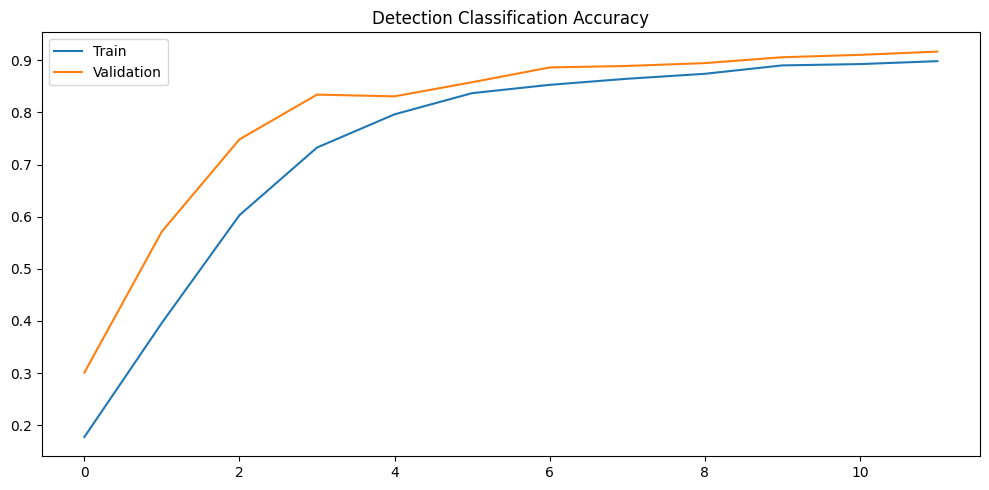

In [19]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(10, 5))
plt.plot(history_df["class_output_accuracy"], label="Train")
plt.plot(history_df["val_class_output_accuracy"], label="Validation")
plt.title("Detection Classification Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Total Loss Curve:**

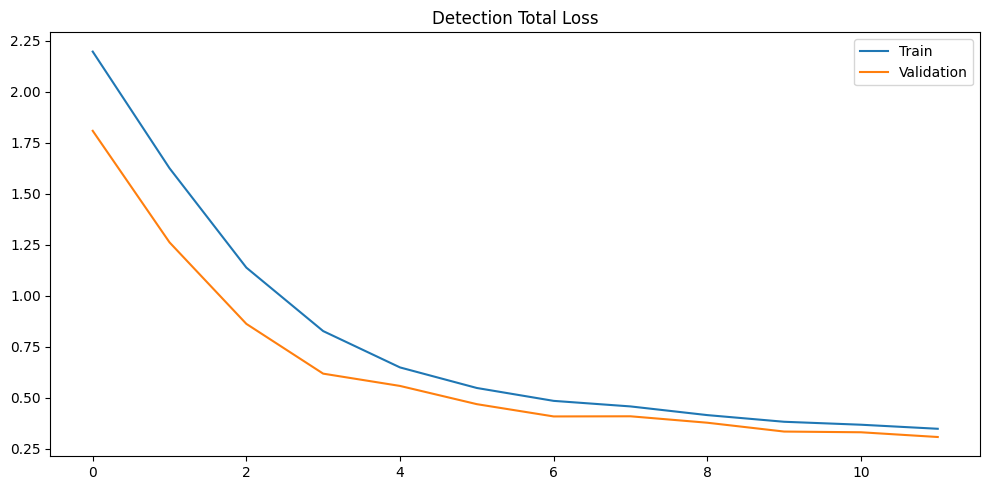

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Train")
plt.plot(history_df["val_loss"], label="Validation")
plt.title("Detection Total Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Predict on Validation and Test Sets:**

In [21]:
val_class_proba, val_box_pred = det_model.predict(X_val, verbose=0)
test_class_proba, test_box_pred = det_model.predict(X_test, verbose=0)

val_class_pred = np.argmax(val_class_proba, axis=1)
test_class_pred = np.argmax(test_class_proba, axis=1)

### **Classification Accuracy:**

In [22]:
val_acc = accuracy_score(y_val_class, val_class_pred)
test_acc = accuracy_score(y_test_class, test_class_pred)
print(val_acc, test_acc)

0.9166666666666666 0.9323333333333333


### **Bounding Box IoU:**

In [23]:
val_iou = iou_boxes_np(y_val_box, val_box_pred).mean()
test_iou = iou_boxes_np(y_test_box, test_box_pred).mean()
print(val_iou, test_iou)

0.35234687 0.34864375


### **Compare Baseline vs Detection CNN:**

In [24]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Detection CNN"],
    "Validation_Class_Acc": [baseline_val_acc, val_acc],
    "Test_Class_Acc": [baseline_test_acc, test_acc],
    "Validation_IoU": [baseline_val_iou, val_iou],
    "Test_IoU": [baseline_test_iou, test_iou]
})
comparison_df

,Model,Validation_Class_Acc,Test_Class_Acc,Validation_IoU,Test_IoU
0,Baseline,0.190417,0.177000,0.371254,0.367875
1,Detection CNN,0.916667,0.932333,0.352347,0.348644


### **Classification Report:**

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test_class, test_class_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9402    0.9626    0.9513       294
           1     0.9969    0.9846    0.9907       325
           2     0.9222    0.9086    0.9153       339
           3     0.8584    0.9532    0.9033       299
           4     0.9251    0.9827    0.9530       289
           5     0.9696    0.8544    0.9084       261
           6     0.9759    0.9279    0.9513       305
           7     0.9536    0.9290    0.9412       310
           8     0.8786    0.9111    0.8945       270
           9     0.9142    0.8994    0.9067       308

    accuracy                         0.9323      3000
   macro avg     0.9335    0.9313    0.9316      3000
weighted avg     0.9340    0.9323    0.9324      3000



### **Per-Class Precision, Recall, F1:**

In [26]:
precision, recall, f1, support = precision_recall_fscore_support(y_test_class, test_class_pred)
metrics_df = pd.DataFrame({
    "digit": list(range(10)),
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
})
metrics_df.head()

,digit,precision,recall,f1_score,support
0,0,0.940199,0.962585,0.951261,294
1,1,0.996885,0.984615,0.990712,325
2,2,0.922156,0.908555,0.915305,339
3,3,0.858434,0.953177,0.903328,299
4,4,0.925081,0.982699,0.953020,289


### **Box Error Diagnostics:**

In [27]:
box_mae = np.abs(y_test_box - test_box_pred).mean(axis=0)
pd.DataFrame({"coord": ["x1","y1","x2","y2"], "mae": box_mae})

,coord,mae
0,x1,0.134415
1,y1,0.134576
2,x2,0.134260
3,y2,0.133177


### **IoU Distribution:**

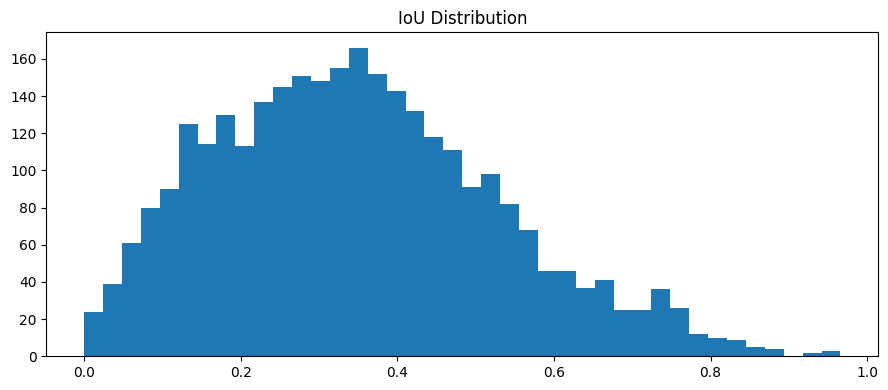

In [28]:
iou_per_sample = iou_boxes_np(y_test_box, test_box_pred)
plt.figure(figsize=(9, 4))
plt.hist(iou_per_sample, bins=40)
plt.title("IoU Distribution")
plt.tight_layout()
plt.show()

### **Best Detection Examples:**

In [29]:
best_idx = np.argsort(iou_per_sample)[-6:]
best_idx

array([ 621, 2419,  443, 2528, 1357,  951], dtype=int64)

### **Visualize Best Detections:**

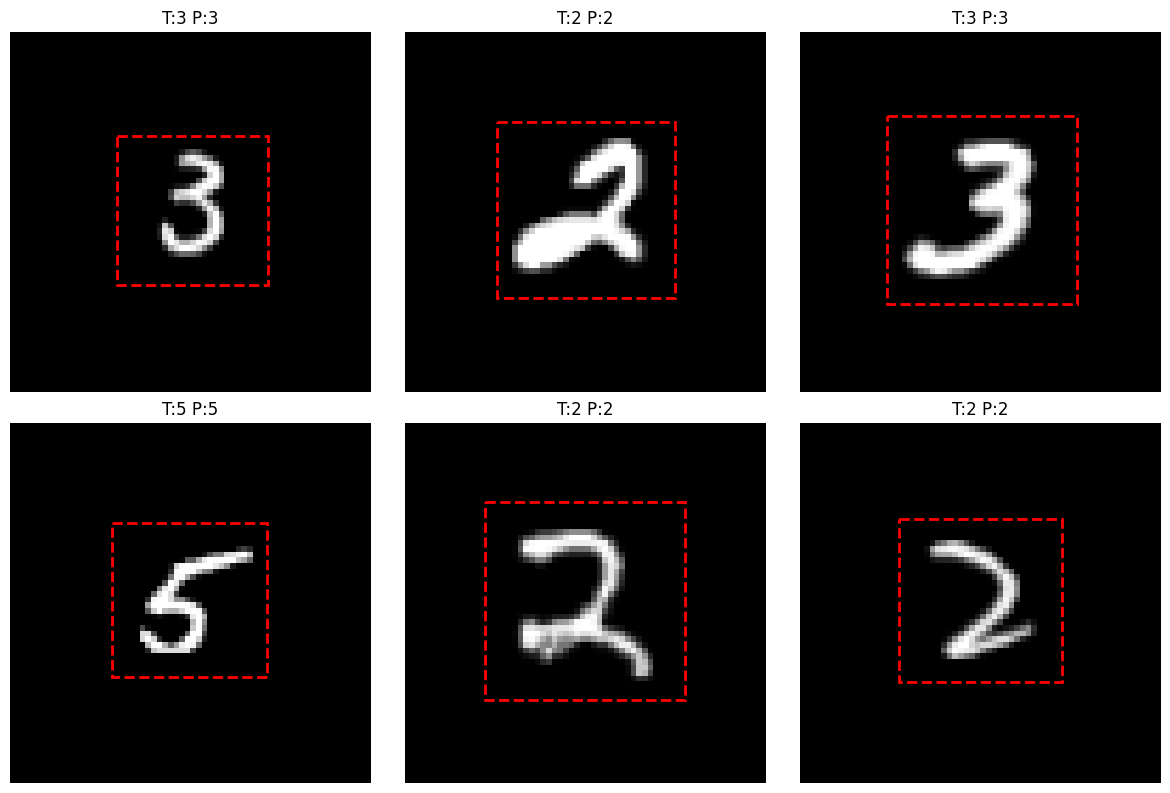

In [30]:
plt.figure(figsize=(12, 8))
for i, idx in enumerate(best_idx):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    x1, y1, x2, y2 = y_test_box[idx] * 64
    rect1 = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
    ax.add_patch(rect1)
    px1, py1, px2, py2 = test_box_pred[idx] * 64
    rect2 = plt.Rectangle((px1, py1), px2-px1, py2-py1, fill=False, linewidth=2, linestyle="--", color="r")
    ax.add_patch(rect2)
    plt.axis("off")
    ax.set_title(f"T:{y_test_class[idx]} P:{test_class_pred[idx]}")
plt.tight_layout()
plt.show()

### **Worst Detection Examples:**

In [31]:
worst_idx = np.argsort(iou_per_sample)[:6]
worst_idx

array([2224,  821, 1581,  971, 1538, 2119], dtype=int64)

### **Visualize Worst Detections:**

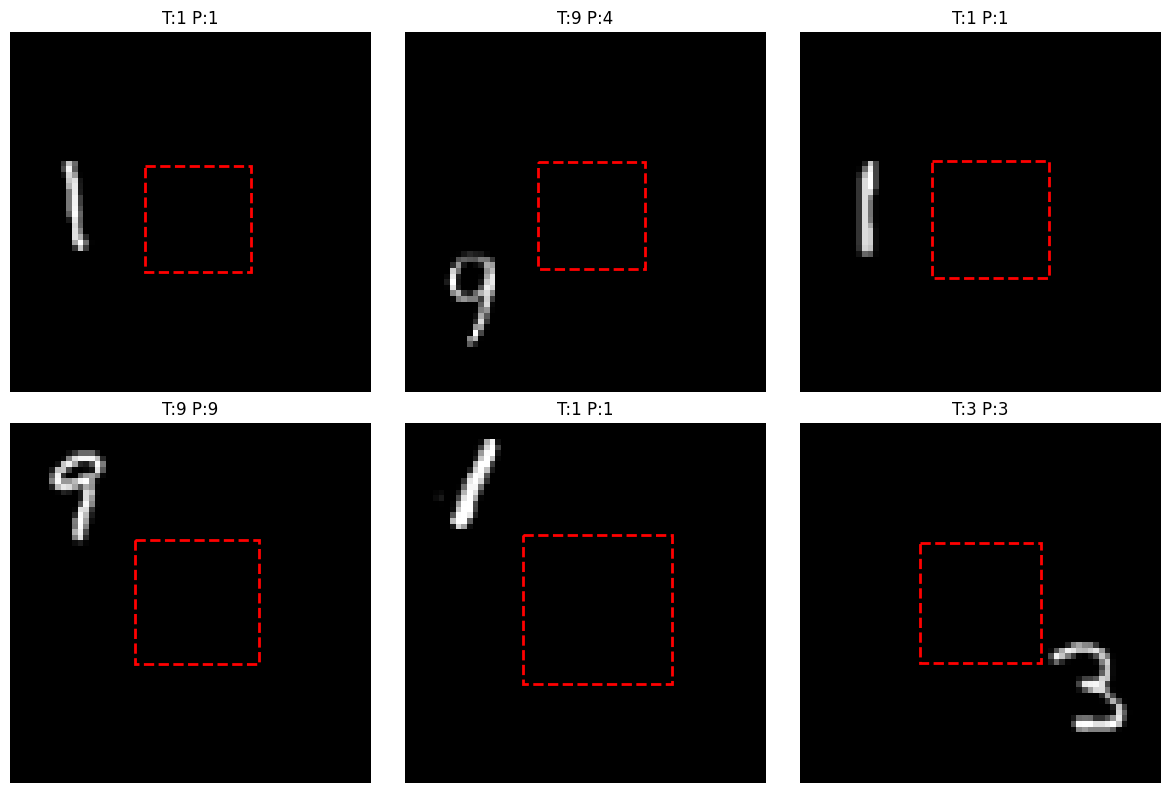

In [32]:
plt.figure(figsize=(12, 8))
for i, idx in enumerate(worst_idx):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    x1, y1, x2, y2 = y_test_box[idx] * 64
    rect1 = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
    ax.add_patch(rect1)
    px1, py1, px2, py2 = test_box_pred[idx] * 64
    rect2 = plt.Rectangle((px1, py1), px2-px1, py2-py1, fill=False, linewidth=2, linestyle="--", color="r")
    ax.add_patch(rect2)
    plt.axis("off")
    ax.set_title(f"T:{y_test_class[idx]} P:{test_class_pred[idx]}")
plt.tight_layout()
plt.show()

### **Classification Confidence Diagnostics:**

In [33]:
pred_confidence = test_class_proba.max(axis=1)
print(pred_confidence.mean(), np.median(pred_confidence))

0.91665745 0.9817653


### **High-IoU Examples with Low Confidence:**

In [34]:
df_cases = pd.DataFrame({
    "idx": np.arange(len(y_test_class)),
    "iou": iou_per_sample,
    "confidence": pred_confidence,
    "true": y_test_class,
    "pred": test_class_pred
})
df_cases.sort_values(["iou", "confidence"], ascending=[False, True]).head(10)

,idx,iou,confidence,true,pred
951,951,0.965846,0.740384,2,2
1357,1357,0.949801,0.987296,2,2
2528,2528,0.947897,0.994061,5,5
443,443,0.939703,0.985996,3,3
2419,2419,0.925544,0.998692,2,2
621,621,0.881687,0.983932,3,3
596,596,0.877982,0.835926,0,0
2153,2153,0.875007,0.978004,5,5
241,241,0.871427,0.758201,8,8
1306,1306,0.866640,0.921910,9,9


### **Top-3 Classification Accuracy:**

In [35]:
top3_pred = np.argsort(test_class_proba, axis=1)[:, -3:]
top3_hit = [int(y_test_class[i] in top3_pred[i]) for i in range(len(y_test_class))]
top3_acc = np.mean(top3_hit)
print(top3_acc)

0.989


### **Save Model Artifacts:**

In [36]:
model_path = MODEL_DIR / "cnn_detector.keras"
metrics_path = MODEL_DIR / "metrics.json"
det_model.save(model_path)
metrics = {
    "baseline_test_class_acc": float(baseline_test_acc),
    "baseline_test_iou": float(baseline_test_iou),
    "detector_test_class_acc": float(test_acc),
    "detector_test_iou": float(test_iou),
    "top3_accuracy": float(top3_acc),
    "seed": SEED
}
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)
print(model_path)
print(metrics_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Object Detection using CNN\artifacts_object_detection_cnn\models\cnn_detector.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Object Detection using CNN\artifacts_object_detection_cnn\models\metrics.json


### **Reload Model for Inference Check:**

In [37]:
reloaded_model = tf.keras.models.load_model(model_path)
sample_outputs = reloaded_model.predict(X_test[:5], verbose=0)
len(sample_outputs)

2

### **Final Metrics Summary Table:**

In [38]:
summary_table = pd.DataFrame({
    "Metric": ["Baseline Class Accuracy", "Baseline IoU", "Detection Class Accuracy", "Detection IoU", "Top-3 Accuracy"],
    "Value": [baseline_test_acc, baseline_test_iou, test_acc, test_iou, top3_acc]
})
summary_table

,Metric,Value
0,Baseline Class Accuracy,0.177000
1,Baseline IoU,0.367875
2,Detection Class Accuracy,0.932333
3,Detection IoU,0.348644
4,Top-3 Accuracy,0.989000


### **Project Summary**

This project presents a complete implementation of an **Object Detection System using CNN-based models**, focusing on identifying and localizing objects within images.

The workflow begins with preprocessing image data and annotations, ensuring that both images and bounding box labels are properly formatted for training.

The core of the system is a **CNN-based object detection model**, which performs two key tasks:

- **Classification**
  - identifies the object category  

- **Localization**
  - predicts bounding box coordinates  

The model learns patterns such as:
- object shapes and structures  
- spatial positioning of objects  
- relationships between objects and background  

The architecture includes:
- convolutional layers for feature extraction  
- detection layers for bounding box prediction  
- classification layers for object labels  

Depending on implementation, the model may follow approaches such as:
- region-based detection (R-CNN family)  
- single-shot detection (YOLO / SSD style concepts)  

A key strength of this project is its ability to perform **end-to-end detection**, combining both classification and localization in a single pipeline.

Evaluation is performed using:
- Intersection over Union (IoU)  
- mean Average Precision (mAP)  
- precision and recall  

The system can be used in real-world applications to:
- detect objects in real-time  
- monitor environments  
- automate visual inspection tasks  

Overall, this project demonstrates advanced computer vision techniques and showcases the ability to build **real-world object detection systems using deep learning**.

### **Key Highlights**

- Built an **Object Detection system using CNN-based models**, targeting advanced computer vision applications.

- Addressed complex problem:
  - simultaneous object classification and localization  

- Utilized dataset with:
  - images and bounding box annotations  

- Implemented a complete **image and annotation preprocessing pipeline**, including:
  - resizing  
  - normalization  
  - label encoding  

- Designed a **CNN-based detection architecture**, capable of:
  - detecting multiple objects  
  - predicting bounding boxes  

- Enabled the model to capture:
  - spatial relationships  
  - object positioning  

- Evaluated model performance using:
  - IoU (Intersection over Union)  
  - mAP (mean Average Precision)  

- Performed **detection analysis**, enabling:
  - evaluation of localization accuracy  
  - identification of missed detections  

- Enabled **real-world applications**, including:
  - autonomous driving  
  - surveillance systems  
  - robotics  

- Designed for **deployment scenarios**, including:
  - real-time detection systems  
  - edge AI applications  
  - production pipelines  

- Demonstrates strong expertise in:
  - **object detection models**  
  - **CNN architectures**  
  - **visual localization techniques**